In [18]:
import numpy as np
import pandas as pd

In [19]:
np.random.seed(42)
n = 150

rainfall = np.random.normal (180,40,n)
temperature = np.random.normal (27,2,n)
fertilizer = np.random.normal (110,20,n)

yield_data = -0.0008*(rainfall-180)**2+\
0.03*fertilizer+\
np.random.normal(0,1,n)

df = pd.DataFrame({
    "rainfall":rainfall,
    "temperature":temperature,
    "fertilizer":fertilizer,
    "yield":yield_data
})

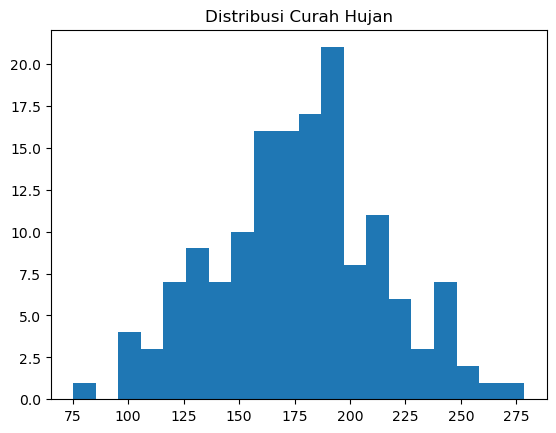

In [20]:
import matplotlib.pyplot as plt

plt.hist(df["rainfall"], bins=20)
plt.title("Distribusi Curah Hujan")
plt.show()

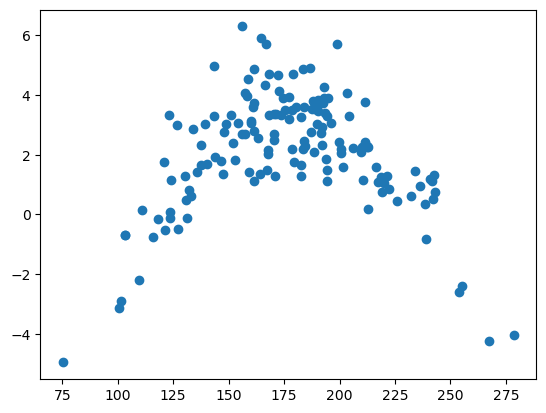

In [21]:
plt.scatter(df["rainfall"], df["yield"])
plt.show()

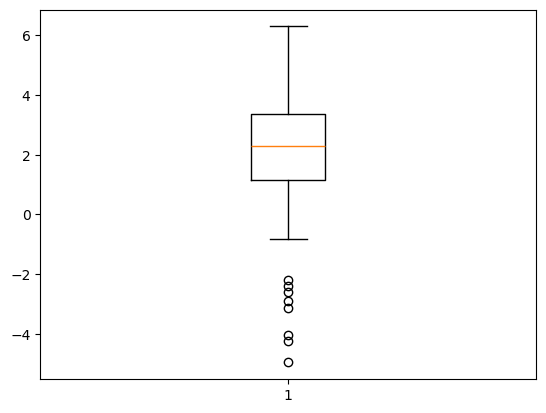

In [22]:
plt.boxplot(df["yield"])
plt.show()

In [23]:
df["rainfall_squared"]=df["rainfall"]**2

In [24]:
from sklearn.linear_model import LinearRegression
X = df[["rainfall","rainfall_squared","temperature","fertilizer"
]]
y = df["yield"]
model = LinearRegression()
model.fit(X,y)
y_pred = model.predict(X)

In [25]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y,y_pred)
print(mae)

0.7609582720105713


In [26]:
from sklearn.cluster import KMeans
X_cluster = df[["rainfall","fertilizer"]]
kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(X_cluster)

c:\Users\hafid\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


c:\Users\hafid\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\hafid\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\hafid\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\hafid\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

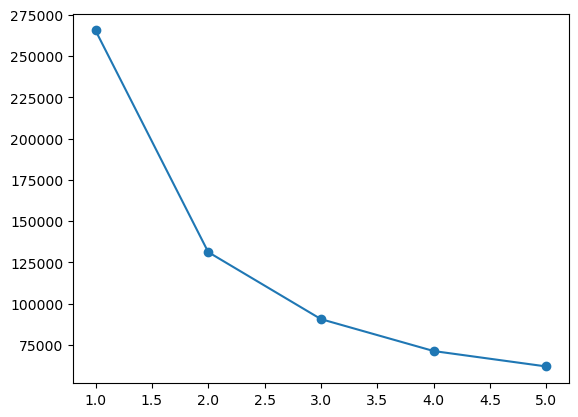

In [31]:
inertia = []
K = range(1,6)

for k in K:
    kmeans = KMeans(n_clusters = k)
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.show()

In [32]:
X_cluster = df[["rainfall", "fertilizer"]]
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_cluster)

c:\Users\hafid\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [ ]:
X_cluster = df[["rainfall", "fertilizer"]]
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_cluster)

In [34]:
print(df.head())

     rainfall  temperature  fertilizer     yield  rainfall_squared  cluster
0  199.868566    27.500986   93.420100  2.424116      39947.443723        2
1  174.469428    27.692896   98.796379  3.894564      30439.581290        2
2  205.907542    25.639951  124.945872  2.225690      42397.915656        1
3  240.921194    27.464507  122.207405  1.201155      58043.021842        1
4  170.633865    27.586145  109.581968  2.687022      29115.915889        2


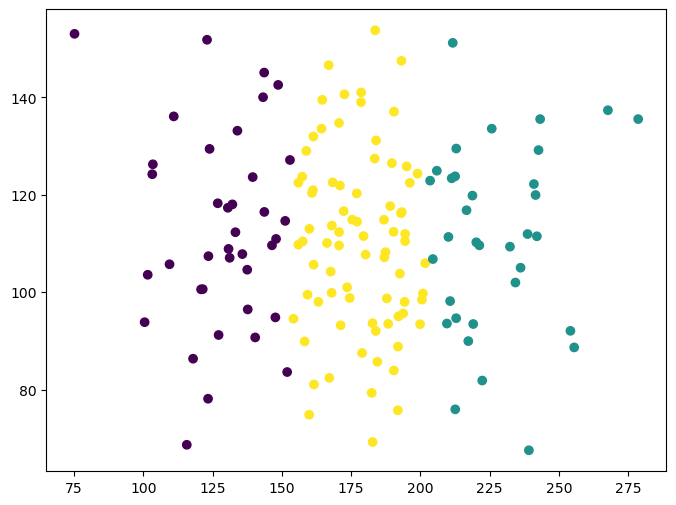

In [35]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["rainfall"],
    df["fertilizer"],
    c=df["cluster"]
)

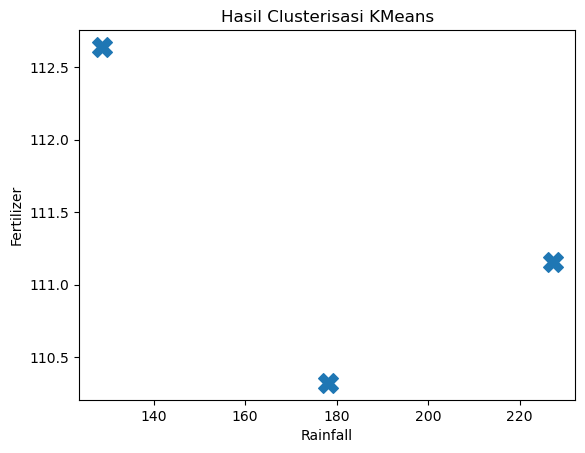

In [36]:
centroids = kmeans.cluster_centers_

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    marker='X',
    s=200
)

plt.xlabel("Rainfall")
plt.ylabel("Fertilizer")
plt.title("Hasil Clusterisasi KMeans")

plt.show()